In [ ]:
pip install ipywidgets matplotlib numpy scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.8 MB/s eta 0:00:00


In [ ]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 51.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Load CSV data
df = pd.read_csv("sample_simplified_eeg_dataset.csv")
df.head()


,Time (s),Fp1,Fp2,Fpz,F3,F4,C1,C2,PO3,PO4,O1,O2,H EOG left,H EOG right,V EOG left,V EOG right,Bias,Ref
0,0.000000,4.967142,-10.138960,-13.805987,5.327832,16.857018,15.947620,-16.130168,-18.658398,-10.206250,-2.956656,9.015180,-12.241093,14.126678,23.015177,-19.356891,-7.510296,2.650731
1,0.003908,10.771018,13.010532,7.792106,4.098394,5.691238,1.998586,12.848442,12.438350,3.993019,15.989332,15.452587,21.034103,9.939952,22.919837,1.277633,10.522722,22.166960
2,0.007816,30.055180,14.324049,21.002090,21.427157,18.792752,21.299452,17.891238,33.368653,19.374742,33.974618,29.015104,38.371339,12.270253,15.085125,34.017051,33.243693,24.042315
3,0.011723,48.818905,36.142444,32.892272,49.011372,38.745212,34.544682,43.251394,27.157066,43.580102,23.223480,44.577314,18.642827,38.679290,36.047612,40.562698,49.270200,23.247509
4,0.015631,39.242601,32.630671,48.475779,51.527650,57.802872,31.980604,27.110174,29.318529,53.568958,51.693230,36.627858,39.872023,37.673566,38.936967,33.080195,52.697688,40.692696


#2D Line Plot of EEG Signals Over Time


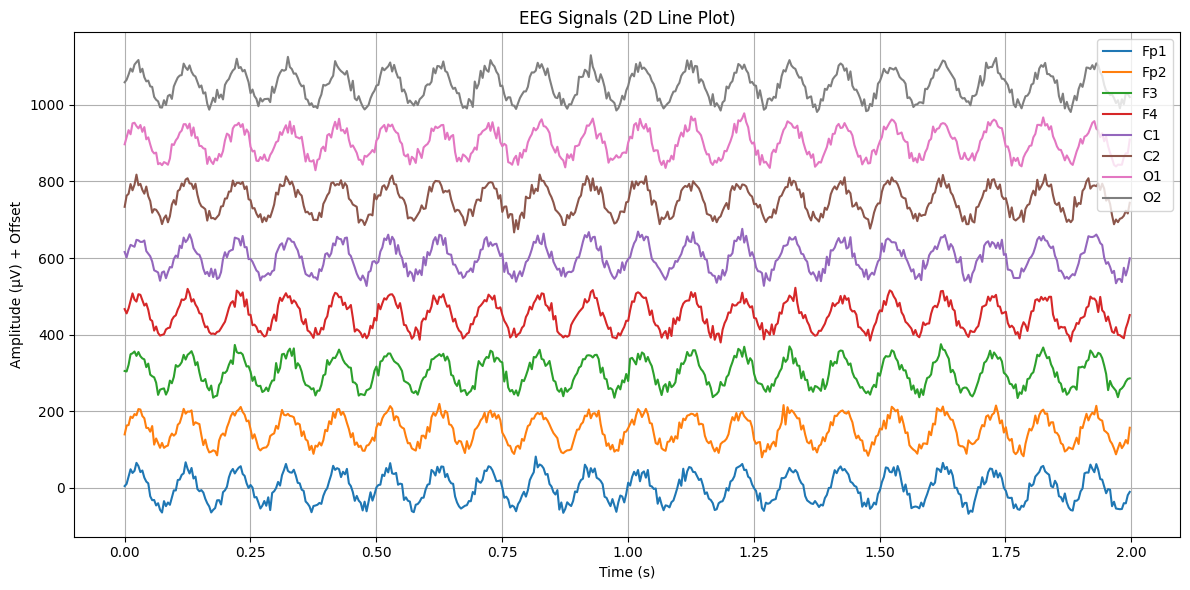

In [ ]:
import matplotlib.pyplot as plt

# Select some channels to show
channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C1', 'C2', 'O1', 'O2']
time = df['Time (s)']

plt.figure(figsize=(12, 6))
for i, ch in enumerate(channels):
    plt.plot(time[:512], df[ch][:512] + i * 150, label=ch)  # offset for clarity

plt.title("EEG Signals (2D Line Plot)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV) + Offset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🧠 Explanation: This shows brain waves from multiple areas over 2 seconds. Each signal is shifted up to avoid overlap.



This plot shows how the brain’s electrical activity changes over time for different regions of the scalp.

The X-axis represents time in seconds.

The Y-axis shows the EEG signal amplitude, which reflects the strength of the brain’s electrical activity.

Each colored line represents a different EEG channel (like Fp1, F3, O1, etc.), corresponding to a specific location on the head.

The signals are vertically offset from each other to make them easier to view and compare (otherwise, the lines would overlap).

# Heatmap of EEG Channel Power

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

# Select channels
channel_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C1', 'C2', 'O1', 'O2']

# Prepare the EEG power data
eeg_power = df[channel_names].apply(np.abs).T  # Transpose so channels are rows

# Create interactive heatmap
fig = px.imshow(
    eeg_power,
    labels=dict(x="Time Index", y="EEG Channel", color="Power (µV)"),
    x=np.arange(eeg_power.shape[1]),
    y=channel_names,
    color_continuous_scale='Plasma'  # You can try 'Viridis', 'Cividis', etc.
)

fig.update_layout(
    title="Interactive EEG Power Heatmap",
    autosize=True,
    height=500
)

fig.show()


🧠 Explanation: Bright areas = high signal power.


"Dark areas mean low brain signal power; bright or hot-colored areas show regions firing more actively. This helps us visually scan where the brain is 'lit up' over time."

Think of this as a weather map for your brain. Bright colors show where activity is strong — like thunderclouds of brain energy! You can easily spot which parts of the brain are more active at different times.


# 3D Surface Plot of Real EEG Data Over Time and Channels

In [ ]:
import plotly.graph_objects as go
import numpy as np
from scipy.interpolate import griddata

# Simulated 2D electrode positions (top of head layout)
positions = {
    'Fp1': (-2, 4), 'Fp2': (2, 4),
    'F3': (-2, 2), 'F4': (2, 2),
    'C1': (-2, 0), 'C2': (2, 0),
    'O1': (-2, -2), 'O2': (2, -2)
}

# Use EEG snapshot at time t
t_idx = 200
X = np.array([positions[ch][0] for ch in channels])
Y = np.array([positions[ch][1] for ch in channels])
Z = np.array([df[ch][t_idx] for ch in channels])

# Create a grid for interpolation
grid_x, grid_y = np.mgrid[-2.5:2.5:100j, -2.5:4.5:100j]
grid_z = griddata((X, Y), Z, (grid_x, grid_y), method='cubic')

# Plotly 3D Surface plot
fig = go.Figure(data=[
    go.Surface(z=grid_z, x=grid_x, y=grid_y, colorscale='Plasma')
])

fig.update_layout(
    title=f"3D EEG Terrain (Interpolated Surface) at t = {df['Time (s)'][t_idx]:.2f}s",
    scene=dict(
        xaxis_title='X (Head)',
        yaxis_title='Y (Head)',
        zaxis_title='EEG Amplitude (µV)',
        aspectmode='cube'
    ),
    margin=dict(l=10, r=10, b=10, t=40)
)

fig.show()


🎯Bird’s-Eye View of the Brain

This 3D plot shows brain activity captured by EEG sensors at a single moment in time. Each point on the surface represents a specific location on the scalp where an EEG electrode is placed — like Fp1 (front left), F3 (frontal), C1 (central), O1 (back left), and so on.

The X and Y axes represent the spatial layout of these electrodes on the head, while the height (Z-axis) shows how strong the brain’s electrical signal is at that location, measured in microvolts (µV).

The smooth, colored surface is created by filling in the gaps between the electrode points using interpolation. This makes the plot look like a "terrain map" or landscape, where peaks represent areas of higher brain activity.

This visualization helps us understand which parts of the brain are more active at a given time — in a way that’s easy to see and explore.


# 3D Interpolated EEG Topographic Map at a Single Time Point


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Load your EEG data
df = pd.read_csv("sample_simplified_eeg_dataset.csv")

# Select channels to visualize
channel_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C1', 'C2', 'O1', 'O2']
n_channels = len(channel_names)

# Select time range (e.g., first 500 points)
n_times = 500
time = df['Time (s)'][:n_times].values

# Extract EEG data for selected channels
eeg_data = np.array([df[ch][:n_times].values for ch in channel_names])

# Create 3D surface plot
fig3d = go.Figure(data=[go.Surface(
    z=eeg_data,
    x=time,
    y=np.arange(n_channels),
    colorscale='Viridis',
    colorbar=dict(title='Amplitude (μV)')
)])

fig3d.update_layout(
    title='3D Surface of Real EEG Data',
    scene=dict(
        xaxis_title='Time (s)',
        yaxis_title='Channels',
        yaxis=dict(tickvals=np.arange(n_channels), ticktext=channel_names),
        zaxis_title='Amplitude (μV)'
    ),
    height=600
)

fig3d.show()


🧠
This 3D surface plot shows how brainwave signals change over time and across different brain regions.

The X-axis represents time in seconds — we’re looking at a short recording of 500 time points.

The Y-axis shows the EEG channels (like Fp1, F3, O1), which are electrodes placed on different parts of the scalp.

The Z-axis shows the EEG signal strength (amplitude in microvolts) — higher values mean stronger electrical activity at that time and location.

Each ridge on the surface corresponds to a different EEG channel, and the wave-like pattern shows how the signal rises and falls as brain activity changes.

This plot helps us visually track how brain signals evolve in different regions. Instead of looking at flat lines, we get a “landscape view” of how the brain behaves — almost like watching the brain breathe!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import ipywidgets as widgets
from IPython.display import display, clear_output

# === Sampling parameters ===
fs = 250  # Sampling frequency (Hz)
t = np.linspace(0, 5, 5 * fs)  # 5 seconds

# === Brainwave frequency bands ===
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta':  (13, 30)
}

state_mapping = {
    'Delta': "Sleeping (Deep Sleep)",
    'Theta': "Drowsy or Meditative",
    'Alpha': "Relaxed & Calm",
    'Beta':  "Focused or Stressed"
}

band_colors = {
    'Delta': '#D0E6A5',
    'Theta': '#FFDD94',
    'Alpha': '#FA897B',
    'Beta': '#CCABD8'
}

# === EEG Signal Generator ===
def generate_signal(state):
    freq_dict = {
        'Sleep': 2,       # Delta
        'Drowsy': 6,      # Theta
        'Relaxed': 10,    # Alpha
        'Focused': 20     # Beta
    }
    freq = freq_dict.get(state, 15)
    signal = 30 * np.sin(2 * np.pi * freq * t) + np.random.normal(0, 5, len(t))
    return signal

# === Classify dominant brainwave ===
def classify_brain_state(signal):
    freqs, psd = welch(signal, fs, nperseg=256)
    band_powers = {}
    for band, (low, high) in bands.items():
        idx = np.logical_and(freqs >= low, freqs <= high)
        band_powers[band] = np.trapz(psd[idx], freqs[idx])
    dominant_band = max(band_powers, key=band_powers.get)
    return dominant_band, freqs, psd

# === Plot and classify with enhanced visuals ===
def plot_and_classify(state):
    clear_output(wait=True)
    signal = generate_signal(state)
    dominant_band, freqs, psd = classify_brain_state(signal)

    plt.figure(figsize=(12, 6))
    plt.plot(freqs, psd, color='darkblue', linewidth=2)
    plt.title(f"EEG Power Spectrum - Simulated State: {state}", fontsize=14)
    plt.xlabel("Frequency (Hz)", fontsize=12)
    plt.ylabel("Power (µV²/Hz)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(0, 40)

    # Highlight brainwave bands with color spans
    for band, (low, high) in bands.items():
        plt.axvspan(low, high, color=band_colors[band], alpha=0.3, label=f'{band} Band')

    plt.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

    print("🔎 Dominant Frequency Band:", dominant_band)
    print("🧠 Estimated Brain State:", state_mapping[dominant_band])

# === Interactive Button Widget ===
state_selector = widgets.ToggleButtons(
    options=['Sleep', 'Drowsy', 'Relaxed', 'Focused'],
    description='Select State:',
    button_style='info',
    style={'button_width': '100px'}
)

# === Launch interactive demo ===
widgets.interact(plot_and_classify, state=state_selector)


interactive(children=(ToggleButtons(button_style='info', description='Select State:', options=('Sleep', 'Drows…

<function __main__.plot_and_classify(state)>

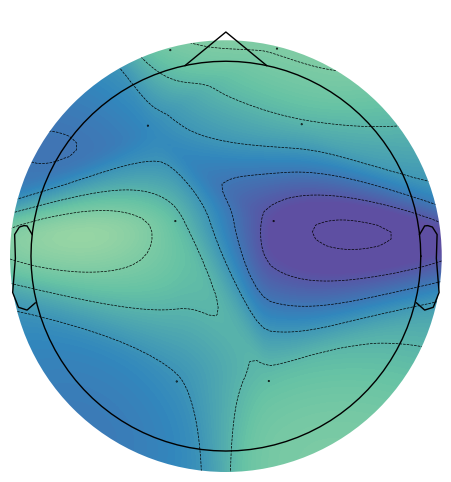

(<matplotlib.image.AxesImage at 0x7da5d9b5b810>,
 <matplotlib.contour.QuadContourSet at 0x7da5d9bcff90>)

In [ ]:
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt

# Step 1: Load EEG dataset
df = pd.read_csv("sample_simplified_eeg_dataset.csv")

# Step 2: Select channels and a time point
channel_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C1', 'C2', 'O1', 'O2']
t_idx = 200  # Time index to plot (change to see other moments)
eeg_values = np.array([df[ch][t_idx] for ch in channel_names])  # EEG snapshot (µV)

# Step 3: Create MNE info object
info = mne.create_info(ch_names=channel_names, sfreq=250, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

# Step 4: Plot Topomap with better colors and size
fig, ax = plt.subplots(figsize=(7, 6))  # Bigger figure
mne.viz.plot_topomap(eeg_values, info, cmap='Spectral_r', size=3, axes=ax, show=True)


In [ ]:
pip install sounddevice


In [ ]:
import numpy as np
import scipy.io.wavfile as wavfile

fs = 44100  # Audio sample rate
duration = 5.0  # seconds per tone

# Brain state to frequency
state_frequencies = {
    "Sleep": 100,
    "Drowsy": 200,
    "Relaxed": 400,
    "Focused": 800
}

def save_brainwave_sound(state):
    freq = state_frequencies[state]
    print(f"🎧 Saving tone for {state} ({freq} Hz)")

    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    tone = 0.5 * np.sin(2 * np.pi * freq * t)

    # Normalize and convert to 16-bit PCM
    tone_pcm = np.int16(tone * 32767)
    wavfile.write(f"{state}_brainwave.wav", fs, tone_pcm)

# Save tones for all states
for state in state_frequencies:
    save_brainwave_sound(state)


🎧 Saving tone for Sleep (100 Hz)
🎧 Saving tone for Drowsy (200 Hz)
🎧 Saving tone for Relaxed (400 Hz)
🎧 Saving tone for Focused (800 Hz)
